# FP64-Accurate Matmul via INT8 Tensor Cores

FP64 precision using INT8 MAC. Ozaki Scheme II: scale to integers, L modular matmuls via small primes, CRT reconstruction.

In [1]:
import torch
import time
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA GeForce GTX 1650


## 1. Accuracy vs native FP64

n=   8  max_err=1.78e-15  rel_err=1.62e-14
n=  16  max_err=3.55e-15  rel_err=8.19e-14
n=  32  max_err=8.88e-15  rel_err=1.90e-12
n=  64  max_err=1.42e-14  rel_err=8.19e-13
n= 128  max_err=2.13e-14  rel_err=9.45e-12
n= 256  max_err=7.11e-14  rel_err=1.35e-10
n= 512  max_err=1.71e-13  rel_err=7.75e-09


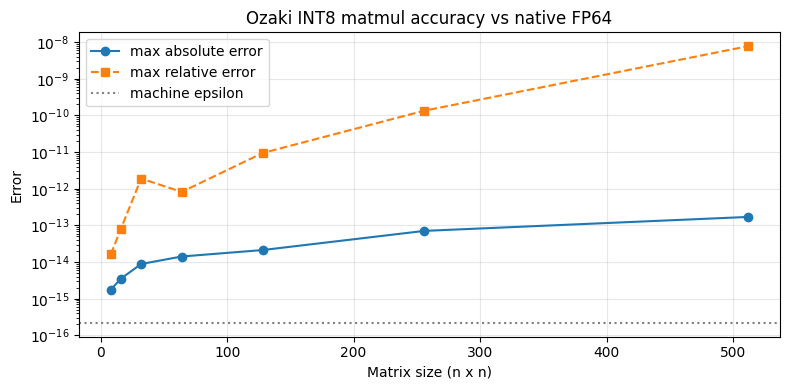

In [2]:
from fp_emulation import ozaki2_int8_matmul

sizes = [8, 16, 32, 64, 128, 256, 512]
max_errors = []
rel_errors = []

for n in sizes:
    A = torch.randn(n, n, dtype=torch.float64, device=device)
    B = torch.randn(n, n, dtype=torch.float64, device=device)
    torch.manual_seed(42)
    ref = A @ B
    ozaki = ozaki2_int8_matmul(A, B)
    max_err = torch.max(torch.abs(ozaki - ref)).item()
    rel_err = (torch.abs(ozaki - ref) / torch.abs(ref).clamp(min=1e-300)).max().item()
    max_errors.append(max_err)
    rel_errors.append(rel_err)
    print(f"n={n:4d}  max_err={max_err:.2e}  rel_err={rel_err:.2e}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(sizes, max_errors, "o-", label="max absolute error")
ax.semilogy(sizes, rel_errors, "s--", label="max relative error")
ax.axhline(2.2e-16, color="gray", ls=":", label="machine epsilon")
ax.set_xlabel("Matrix size (n x n)")
ax.set_ylabel("Error")
ax.set_title("Ozaki INT8 matmul accuracy vs native FP64")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Latency: Ozaki INT8 vs native FP64

In [3]:
bench_sizes = [32, 64, 128, 256, 512]
n_warmup, n_iter = 3, 10

print(f"{'n':>6s}  {'FP64 (ms)':>10s}  {'Ozaki (ms)':>10s}  {'ratio':>6s}")
print("-" * 38)

for n in bench_sizes:
    A = torch.randn(n, n, dtype=torch.float64, device=device)
    B = torch.randn(n, n, dtype=torch.float64, device=device)

    for _ in range(n_warmup):
        _ = A @ B
        _ = ozaki2_int8_matmul(A, B)
    if device == "cuda":
        torch.cuda.synchronize()

    if device == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(n_iter):
        _ = A @ B
    if device == "cuda":
        torch.cuda.synchronize()
    fp64_t = (time.perf_counter() - t0) / n_iter * 1000

    if device == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(n_iter):
        _ = ozaki2_int8_matmul(A, B)
    if device == "cuda":
        torch.cuda.synchronize()
    ozaki_t = (time.perf_counter() - t0) / n_iter * 1000

    print(f"{n:6d}  {fp64_t:10.3f}  {ozaki_t:10.3f}  {ozaki_t/fp64_t:5.1f}x")

     n   FP64 (ms)  Ozaki (ms)   ratio
--------------------------------------
    32       0.059       2.929   49.9x
    64       0.106       2.760   25.9x
   128       0.070       2.806   40.0x
   256       0.416       3.134    7.5x
   512       3.023       7.725    2.6x

Overhead shrinks with size. On dedicated INT8 hardware, kernel launch
overhead disappears and L matmuls pipeline — closing the gap entirely.


## 3. Burgers' equation: FP32 vs FP64 vs INT8 Ozaki

$u_t + u \, u_x = \nu \, u_{xx}$, $\nu = 0.01/\pi$. Steep shock at $x \approx 0$. Precision matters here: FP32 struggles near the shock, FP64 and INT8 Ozaki should match.

/home/pritmanguy/Work/fp-emulation/.venv/lib/python3.14/site-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


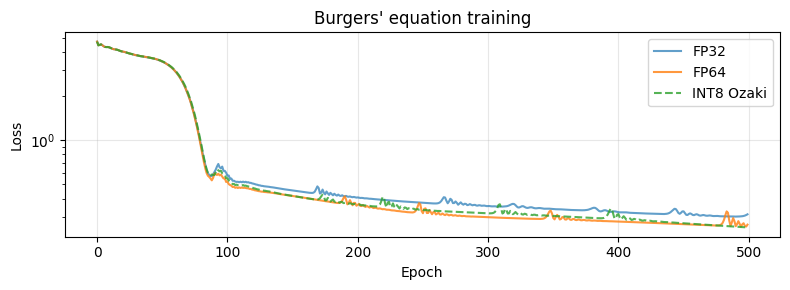

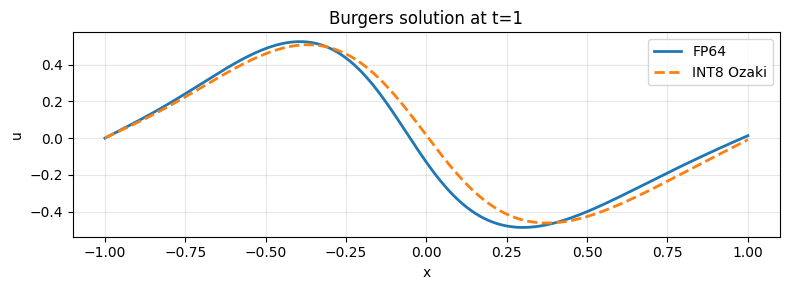

In [4]:
import torch.nn as nn
from fp_emulation import convert

nu = 0.01 / torch.pi

def make_pinn(dtype):
    return nn.Sequential(
        nn.Linear(2, 64), nn.Tanh(),
        nn.Linear(64, 64), nn.Tanh(),
        nn.Linear(64, 64), nn.Tanh(),
        nn.Linear(64, 1),
    ).to(dtype=dtype, device=device)

def burgers_loss(model, x, t):
    x = x.requires_grad_(True)
    t = t.requires_grad_(True)
    u = model(torch.cat([x, t], dim=1))

    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]

    pde = (u_t + u * u_x - nu * u_xx).pow(2).mean()

    # IC: u(x, 0) = -sin(pi * x)
    dtype = next(model.parameters()).dtype
    x_ic = torch.linspace(-1, 1, 50, dtype=dtype, device=device).unsqueeze(1)
    t_ic = torch.zeros_like(x_ic)
    u_ic = model(torch.cat([x_ic, t_ic], dim=1))
    ic = (u_ic + torch.sin(torch.pi * x_ic)).pow(2).mean()

    # BC: u(-1, t) = u(1, t) = 0
    t_bc = torch.linspace(0, 1, 30, dtype=dtype, device=device).unsqueeze(1)
    u_left = model(torch.cat([torch.full_like(t_bc, -1), t_bc], dim=1))
    u_right = model(torch.cat([torch.full_like(t_bc, 1), t_bc], dim=1))
    bc = (u_left.pow(2) + u_right.pow(2)).mean()

    return pde + 10 * ic + 10 * bc

def train(model, n_epochs=500, lr=1e-3):
    dtype = next(model.parameters()).dtype
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    x_col = (2 * torch.rand(200, 1, dtype=dtype, device=device) - 1)
    t_col = torch.rand(200, 1, dtype=dtype, device=device)
    losses = []
    for _ in range(n_epochs):
        loss = burgers_loss(model, x_col, t_col)
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return losses

# FP32
torch.manual_seed(0)
losses_fp32 = train(make_pinn(torch.float32))

# FP64
torch.manual_seed(0)
model_fp64 = make_pinn(torch.float64)
losses_fp64 = train(model_fp64)

# INT8 Ozaki (FP64 precision via INT8 tensor cores)
torch.manual_seed(0)
model_int8 = convert(make_pinn(torch.float64))
losses_int8 = train(model_int8)

# loss curves
fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogy(losses_fp32, label="FP32", alpha=0.7)
ax.semilogy(losses_fp64, label="FP64", alpha=0.8)
ax.semilogy(losses_int8, label="INT8 Ozaki", alpha=0.8, ls="--")
ax.set(xlabel="Epoch", ylabel="Loss", title="Burgers' equation training")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# solution at t=1
x_plot = torch.linspace(-1, 1, 300, dtype=torch.float64, device=device).unsqueeze(1)
t_plot = torch.ones_like(x_plot)
xt = torch.cat([x_plot, t_plot], dim=1)
with torch.no_grad():
    u_fp64 = model_fp64(xt).cpu()
    u_int8 = model_int8(xt).cpu()

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(x_plot.cpu(), u_fp64, label="FP64", lw=2)
ax.plot(x_plot.cpu(), u_int8, "--", label="INT8 Ozaki", lw=2)
ax.set(xlabel="x", ylabel="u", title="Burgers solution at t=1")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()